In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [2]:
df = pd.read_csv(r'C:\Users\Pardhasaradhi\OneDrive\Documents\GitHub\apple-stock-analysis\dataset\AAPL.csv')
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


In [23]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Target'],
      dtype='str')

In [5]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [6]:
# Drop last row (NaN due to shift)
df = df.dropna()

In [36]:
df['Target'] = df['Adj Close'].shift(-1)
df

,Date,Open,High,Low,Close,Adj Close,Volume,Target
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600,0.094952
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800,0.087983
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000,0.090160
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600,0.092774
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600,0.098436
...,...,...,...,...,...,...,...,...
10457,2022-06-03,146.899994,147.970001,144.460007,145.380005,145.380005,88471400,146.139999
10458,2022-06-06,147.029999,148.570007,144.899994,146.139999,146.139999,71598400,148.710007
10459,2022-06-07,144.350006,149.000000,144.100006,148.710007,148.710007,67808200,147.960007
10460,2022-06-08,148.580002,149.869995,147.460007,147.960007,147.960007,53950200,142.639999


In [37]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       1
dtype: int64


In [38]:
df = df.dropna()

In [39]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64


In [40]:
#Feature Selection
#==============================
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully!")


Model Trained Successfully!


In [43]:
# Predictions
# ==============================
y_pred = model.predict(X_test)

In [44]:
# Evaluation
# ==============================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)


Model Performance:
MAE: 6.919627123446347
RMSE: 9.776191381355616


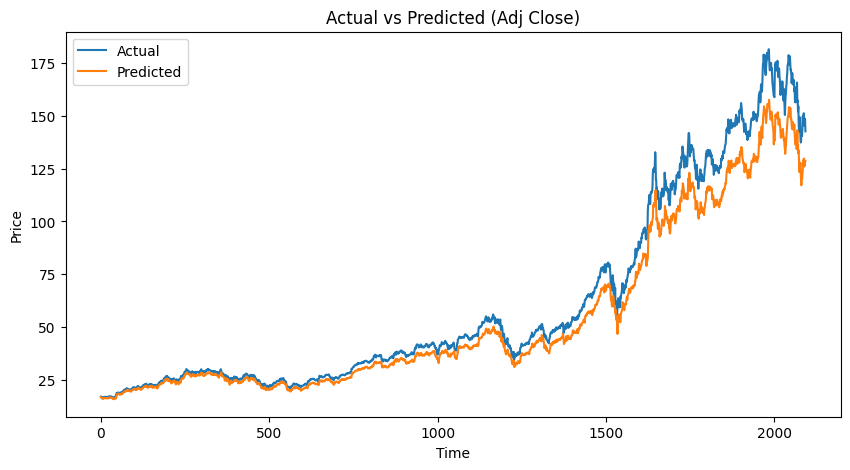

In [45]:
# Visualization
# ==============================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted (Adj Close)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [46]:
# Model Coefficients
# ==============================
print("\nModel Details:")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Model Details:
Intercept: -0.008421101737743797
Coefficients: [-6.14874899e-01  8.23056644e-01  6.54817578e-01 -1.94918526e-11]
